Does solar activity affect the market? 

We will find out by measuring the effect of a (presumably exogeneous) solar activity-related variable on the S&P 500's index.   

# Instructions for running the notebook

Install [uv](https://docs.astral.sh/uv/) on your machine. Mac users can simply run 

```sh
brew install uv
```

Then, execute 

```sh
uv init 
source .venv/bin/activate
uv add ipykernel 
uv add matplotlib
uv add pandas 
uv add yfinance
```

This will allow you to run the cells below. 

# Loading packages

In [81]:
import os
import yfinance
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Loading data

In [67]:
# We will get the daily data from the last 20 years (2005-2025)
raw_data = yfinance.download(
    tickers="^GSPC", start="2005-12-22", end="2025-12-22", interval="1d"
)

# As we are simply analzing the S&P 500 index, we can extract its data from the multi-index dataframe
raw_data = raw_data.xs("^GSPC", level="Ticker", axis=1)
raw_data.head()

/var/folders/29/xv4b56h92vn6yl3hd0k5btw80000gn/T/ipykernel_91573/226207271.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yfinance.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2005-12-22,1268.119995,1268.189941,1262.500000,1262.790039,1888500000
2005-12-23,1268.660034,1269.760010,1265.920044,1268.119995,1285810000
2005-12-27,1256.540039,1271.829956,1256.540039,1268.660034,1540470000
2005-12-28,1258.170044,1261.099976,1256.540039,1256.540039,1422360000
2005-12-29,1254.420044,1260.609985,1254.180054,1258.170044,1382540000


## Analyis

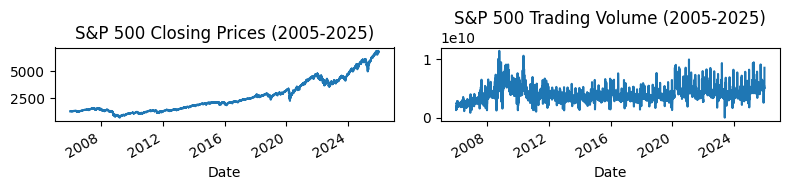

In [98]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
raw_data.Close.plot(title="S&P 500 Closing Prices (2005-2025)")
plt.subplot(1, 2, 2)
raw_data.Volume.plot(title="S&P 500 Trading Volume (2005-2025)")
plt.tight_layout()

Under a standard geometric Brownian motion model, log-returns are normally distributed; we will consider henceforth the effect of the solar activity on the daily log-returns based on the closing prices. 

In [99]:
data = raw_data.copy()
data["LogReturn"] = (data["Close"] / data["Close"].shift(1)).apply(lambda x: np.log(x))
# We drop the first row as it will have NaN log-return
data = data.iloc[1:, :]

# We also include both the Month and Year columns for merging purposes (see below)
data["Year"] = data.index.year
data["Month"] = data.index.month
data["Day"] = data.index.day
assert not data["LogReturn"].isna().any()

data = data[["LogReturn", "Day", "Year", "Month"]]

<Axes: title={'center': 'S&P 500 Daily Log-Returns (2005-2025)'}, xlabel='Date'>

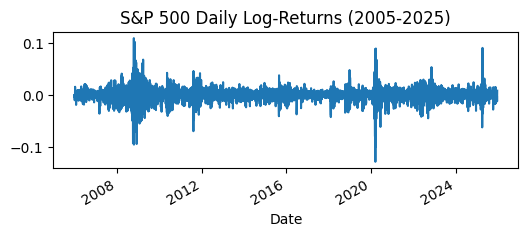

In [100]:
plt.figure(figsize=(6, 2))
data.LogReturn.plot(title="S&P 500 Daily Log-Returns (2005-2025)")

Financial data has been widely studied, and stylized facts regarding their behavior are well known, see, e.g., (McNeil et al., 2005, Chapters 3-4). 
Nonetheless, a comprehensive analysis with sophisticated volatility models (e.g., GARCH) is beyond the scope of this notebook. 
We will focus on a simple OLS-based regression for assessing the relationship between sunspot frequency and the S&P500 returns. 

Towards this objective, we will first fetch the needed information on our chosen exogeneous variable from [SILSO](https://www.sidc.be/SILSO/datafiles). 

In [101]:
filename = "sunspots.csv"
if not os.path.exists(filename):
    !curl -L https://www.sidc.be/SILSO/INFO/snmtotcsv.php -o $filename

In [102]:
# Column info available at https://www.sidc.be/SILSO/infosnmtot.
sunspots = pd.read_csv(
    "sunspots.csv",
    names=[
        "Year",
        "Month",
        "DateFrac",
        "MonthlyMean",
        "MonthlyStdDev",
        "Observations",
        "IsDefinitive",
    ],
    delimiter=";",
)

# We will only need the data after 2005-12
sunspots = sunspots[
    (sunspots["Year"] > 2005) | ((sunspots["Year"] == 2005) & (sunspots["Month"] >= 11))
]
# We create a date column for merging purposes
sunspots["Date"] = pd.to_datetime(
    sunspots["Year"].astype(str) + "-" + sunspots["Month"].astype(str)
)

In [151]:
# Verify whether some months are not covered
def check_missing_months(sunspots):
    dates = pd.to_datetime(
        dict(year=sunspots.Year, month=sunspots.Month, day=1)
    )

    full = pd.date_range(dates.min(), dates.max(), freq="MS")

    missing = full.difference(dates)
    return missing

missing_months = check_missing_months(sunspots)
assert len(missing_months) == 0, f"Missing months: {missing_months}"
# Check for missing values 
assert not sunspots.MonthlyMean.isna().any()

sunspots.head()

,Year,Month,DateFrac,MonthlyMean,MonthlyStdDev,Observations,IsDefinitive,Date,NextMonth
3082,2005,11,2005.874,27.5,4.1,499,1,2005-11-01,12
3083,2005,12,2005.958,59.3,3.9,419,1,2005-12-01,13
3084,2006,1,2006.042,20.9,3.4,511,1,2006-01-01,2
3085,2006,2,2006.123,5.7,3.7,434,1,2006-02-01,3
3086,2006,3,2006.204,17.3,4.2,502,1,2006-03-01,4


We then merge the data sets based on the yearly and monthly data. 
As our `sunspots` data set contains averages from the entire month, we avoid data snooping by only using data from the previous month at each day.

In [152]:
sunspots["NextMonth"] = sunspots["Month"].shift(-1)
# We drop the last row as it will have NaN in NextMonth
sunspots = sunspots.iloc[:-1, :]

sp500_sunspots = data.merge(
    sunspots[["Year", "NextMonth", "MonthlyMean"]],
    left_on=["Year", "Month"],
    right_on=["Year", "NextMonth"],
    how="left",
    suffixes=("", "_Sunspots"),
)

# We drop the NextMonth column (which was only used for merging)
sp500_sunspots = sp500_sunspots.drop(columns=["NextMonth"])

In [153]:
sp500_sunspots.head()

,LogReturn,Day,Year,Month,MonthlyMean
0,0.000426,23,2005,12,27.5
1,-0.009599,27,2005,12,27.5
2,0.001296,28,2005,12,27.5
3,-0.002985,29,2005,12,27.5
4,-0.004899,30,2005,12,27.5


For exploration, we plot both time series. 

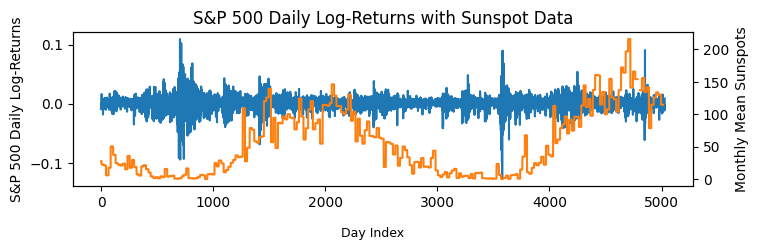

In [154]:
fig = plt.figure(figsize=(8, 2))
ax1 = sp500_sunspots.LogReturn.plot(title="S&P 500 Daily Log-Returns with Sunspot Data")
ax2 = sp500_sunspots.MonthlyMean.plot(secondary_y=True, label="Monthly Mean Sunspots", )

ax1.set_ylabel("S&P 500 Daily Log-Returns")
ax2.set_ylabel("Monthly Mean Sunspots")
fig.supxlabel("Day Index", y=-.16, fontsize=9)

plt.show()